In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import struct
from pathlib import Path
import math
import json
from datetime import datetime
import torch

# 🔥 CUDA оптимизации (ставить здесь)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')


Using device: cuda


In [2]:
class PipeDataset(Dataset):
    def __init__(self, data_list, labels, scaler=None, fit_scaler=False):
        self.data_list = data_list
        self.labels = labels
        if fit_scaler:
            all_data = np.vstack(data_list)
            self.scaler = StandardScaler().fit(all_data)
        else:
            self.scaler = scaler
        self.data_list = [torch.FloatTensor(self.scaler.transform(sample)) for sample in self.data_list]
        self.labels = torch.LongTensor(labels)
    def __len__(self):
        return len(self.data_list)
    def __getitem__(self, idx):
        return self.data_list[idx], self.labels[idx]

def collate_fn(batch):
    data_list, labels = zip(*batch)
    max_len = max([d.shape[0] for d in data_list])
    padded_data, lengths = [], []
    for data in data_list:
        length = data.shape[0]
        lengths.append(length)
        padding = torch.zeros(max_len - length, data.shape[1])
        padded = torch.cat([data, padding], dim=0)
        padded_data.append(padded)
    data_batch = torch.stack(padded_data)
    labels_batch = torch.stack(labels)
    mask = torch.zeros(data_batch.shape[:2])
    for i, length in enumerate(lengths):
        mask[i, :length] = 1
    # Для Transformer: возвращаем data, labels, lengths, mask (в таком порядке как в 1D_CNN.ipynb)
    return data_batch, labels_batch, torch.tensor(lengths), mask


In [3]:
# ============================================
# 🔄 ПОЗИЦИОННОЕ КОДИРОВАНИЕ
# ============================================

class RelationalPositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.2, max_len=500):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * 
                           (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        
        self.register_buffer('pe', pe)
        self.scale = nn.Parameter(torch.tensor(1.0))
        
    def forward(self, x):
        x = x + self.scale * self.pe[:, :x.size(1), :]
        return self.dropout(x)

# ============================================
# 🧠 МОДЕЛЬ PIPE TRANSFORMER
# ============================================

class PipeTransformer(nn.Module):
    d_model=128
    nhead=8
    num_layers=6
    dim_feedforward=128
    dropout=0.2
    def __init__(self, input_channels=8, n_classes=2, 
                 d_model=128, nhead=8, num_layers=6, 
                 dim_feedforward=128, dropout=0.2):
        super().__init__()
        
        self.input_projection = nn.Linear(input_channels, d_model)
        self.pos_encoder = RelationalPositionalEncoding(d_model, dropout)
        self.d_model=d_model
        self.nhead=nhead
        self.num_layers=num_layers
        self.dim_feedforward=dim_feedforward
        self.dropout=dropout
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=False
            #norm_first=True
        )
        
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, 
            num_layers=num_layers,
            norm=nn.LayerNorm(d_model)
        )
        
        self.pooling = nn.AdaptiveAvgPool1d(1)
        
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.LeakyReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes)
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    
    def forward_Old(self, x, src_key_padding_mask=None):
        x = self.input_projection(x) * math.sqrt(x.size(-1))
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x, src_key_padding_mask=src_key_padding_mask)
        
        x = x.transpose(1, 2)
        
        #Удалите self.pooling из класса модели при таком подходе.
        #x = self.pooling(x).squeeze(-1)
        
        # x имеет форму (Batch, Seq_Len, d_model)
        # mask имеет форму (Batch, Seq_Len), 1 где данные, 0 где паддинг
        
        # Расширяем маску до размерности признаков
        mask_expanded = mask.unsqueeze(-1).float()
        
        # Обнуляем паддинг в эмбеддингах
        x_masked = x * mask_expanded
        
        # Суммируем признаки
        sum_features = x_masked.sum(dim=1)
        
        # Считаем количество валидных токенов (избегаем деления на 0)
        valid_counts = mask_expanded.sum(dim=1).clamp(min=1e-9)
        
        # Делим сумму на количество
        x_pooled = sum_features / valid_counts
                
        #return self.classifier(x) 
        return self.classifier(x_pooled) 
    
    def forward(self, x, src_key_padding_mask=None):
        # 1. Проекция и позиционное кодирование
        x = self.input_projection(x) * math.sqrt(x.size(-1))
        x = self.pos_encoder(x)
        
        # 2. Подготовка маски для Transformer (PyTorch ожидает True там, где паддинг)
        # Ваша маска: 1 = данные, 0 = паддинг. Инвертируем для Attention.
        attention_mask = ~src_key_padding_mask.bool() if src_key_padding_mask is not None else None
        
        # 3. Пропускаем через энкодер
        x = self.transformer_encoder(x, src_key_padding_mask=attention_mask)  # (B, L, D)
        
        # 4. Транспонируем для работы с каналами
        x = x.transpose(1, 2)  # (B, D, L)
        
        # 5. Маскированный пулинг (усредняем только по реальным данным)
        if src_key_padding_mask is not None:
            mask = src_key_padding_mask.unsqueeze(1).float()  # (B, 1, L)
            x = x * mask
            # Делим на количество валидных токенов, чтобы паддинг не занижал среднее
            x = x.sum(dim=2) / mask.sum(dim=2).clamp(min=1e-9)
        else:
            x = x.mean(dim=2)
            
        # 6. Классификатор
        return self.classifier(x)
          


In [4]:
def read_raw_file(filepath):
    path = Path(filepath)
    if not path.exists():
        raise FileNotFoundError(f'File not found: {path}')
    with open(path, 'rb') as f:
        data = f.read()
    if len(data) < 17:
        raise ValueError('File too short')
    x = struct.unpack_from('>i', data, 0)[0]
    y = struct.unpack_from('>i', data, 4)[0]
    thicknom = struct.unpack_from('>d', data, 8)[0]
    defective = struct.unpack_from('>B', data, 16)[0]
    num_values = x * y
    matrix = struct.unpack(f'>{num_values}d', data[17:17+num_values*8])
    matrix_np = np.array(matrix, dtype=np.float32).reshape(x, y)
    return {'matrix': matrix_np, 'defective': defective, 'thicknom': thicknom}

def load_dataset_from_folder(folder_path, verbose=True):
    folder = Path(folder_path)
    raw_files = list(folder.glob('*.raw'))
    if not raw_files:
        raise FileNotFoundError(f'No .raw files found in {folder_path}')
    if verbose:
        print(f'Found files: {len(raw_files)}')
    data_list, labels, thicknom_list = [], [], []
    for file_path in raw_files:
        try:
            result = read_raw_file(file_path)
            data_list.append(result['matrix'])
            labels.append(result['defective'])
            thicknom_list.append(result['thicknom'])
        except Exception as e:
            print(f'Error reading {file_path.name}: {e}')
    if verbose:
        print(f'Loaded: {len(data_list)} files')
    return data_list, np.array(labels), thicknom_list


In [5]:
# ============================================
# Scheduler с Warmup
# ============================================

def get_cosine_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps, min_lr=1e-7):
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
    
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


In [6]:
def create_results_folder(epochs, batch_size, learning_rate, base_dir='results'):
    """Создаёт папку для сохранения результатов эксперимента"""
#   timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    folder_name = f"Transformer_{epochs}epochs_{batch_size}batch_{learning_rate}lr_{timestamp}"
    
    results_dir = Path(base_dir) / folder_name
    results_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"\n📁 Папка результатов: {results_dir.absolute()}")
    
    return results_dir, folder_name

def plot_training_history(history, results_dir, folder_prefix, save_name='training_plot.png'):
    """Строит графики потери и точности Transformer"""
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # График потерь
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r--', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Эпоха', fontsize=11)
    axes[0].set_ylabel('Потеря (Loss)', fontsize=11)
    axes[0].set_title('📉 Динамика потери Transformer', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_axisbelow(True)
    
    # График точности
    axes[1].plot(epochs, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    axes[1].plot(epochs, history['val_acc'], 'r--', label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Эпоха', fontsize=11)
    axes[1].set_ylabel('Точность (%)', fontsize=11)
    axes[1].set_title('📈 Динамика точности Transformer', fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_axisbelow(True)
    
    plt.tight_layout()
    
    save_path = results_dir / f"{folder_prefix}_{save_name}"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"💾 График сохранён: {save_path}")
    
    return save_path


In [7]:
# LOAD DATA - CHANGE DATA_FOLDER TO YOUR PATH
DATA_FOLDER = 'dataset'
print('Loading data...')
data_list, labels, thicknom_list = load_dataset_from_folder(DATA_FOLDER)
X_train, X_val, y_train, y_val, thicknom_train, thicknom_val = train_test_split(
    data_list, labels, thicknom_list, test_size=0.2, random_state=42, stratify=labels
)
print(f'Train: {len(X_train)}, Val: {len(X_val)}')
BATCH_SIZE = 32
train_dataset = PipeDataset(X_train, y_train, scaler=None, fit_scaler=True)
val_dataset = PipeDataset(X_val, y_val, scaler=train_dataset.scaler, fit_scaler=False)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0, pin_memory=False)
print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')


Loading data...
Found files: 3486
Loaded: 3486 files
Train: 2788, Val: 698
Train batches: 88, Val batches: 22


In [25]:
# ============================================
# === КОНФИГУРАЦИЯ ===
# ============================================

print("🔥 GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
if torch.cuda.is_available():
    print(f"📊 Память GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

EPOCHS = 250
LEARNING_RATE = 0.0025
N_CLASSES = 2
MODEL_TYPE = 'Transformer'

# 📁 Создаём папку для результатов
results_dir, folder_prefix = create_results_folder(
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    learning_rate=LEARNING_RATE,
    base_dir='results'
)

# ============================================
# === МОДЕЛЬ ===
# ============================================

model = PipeTransformer(
    input_channels=8, 
    n_classes=N_CLASSES,
    d_model=128,
    nhead=8,
    num_layers=12,
    dim_feedforward=256,
    dropout=0.25
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

# Оптимизатор AdamW (лучше для Transformer)
optimizer = optim.AdamW(
    model.parameters(), 
    lr=LEARNING_RATE, 
    weight_decay=1e-4,
    betas=(0.9, 0.98),
    eps=1e-9
)

# Scheduler с warmup
num_warmup = int(EPOCHS * 0.1)
scheduler = get_cosine_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=num_warmup * len(train_loader),
    num_training_steps=EPOCHS * len(train_loader),
    min_lr=1e-7
)

# GradScaler для mixed precision
# Правильная инициализация для новых версий PyTorch
scaler = torch.amp.GradScaler('cuda')
try:
    # Для PyTorch >= 2.4
    scaler = torch.amp.GradScaler('cuda')
except TypeError:
    # Для старых версий
    scaler = torch.cuda.amp.GradScaler()

print(f"\n🚀 Старт обучения Transformer на {DEVICE}")
print(f"📊 Размеров параметров: {sum(p.numel() for p in model.parameters()):,}")
print(f"📁 Результаты будут сохранены в: {results_dir}")
print(f"🎯 Mixed Precision: Enabled")

# ============================================
# === ХРАНИЛИЩЕ ИСТОРИИ ===
# ============================================

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}


🔥 GPU: NVIDIA GeForce GTX 1650
📊 Память GPU: 4.29 GB

📁 Папка результатов: /mnt/d/Универ/ВКР/Код/ПарсингДаных/DataTransform/scientificProject/results/Transformer_250epochs_32batch_0.0025lr_20260427_211817

🚀 Старт обучения Transformer на cuda
📊 Размеров параметров: 1,599,555
📁 Результаты будут сохранены в: results/Transformer_250epochs_32batch_0.0025lr_20260427_211817
🎯 Mixed Precision: Enabled


In [26]:
# ============================================
# 📈 ФУНКЦИИ ОБУЧЕНИЯ И ОЦЕНКИ (с Mixed Precision)
# ============================================

import torch
import gc

def train_epoch(model, loader, criterion, optimizer, device, accumulation_steps=4):
    """Обучение за одну эпоху (FP32 + Gradient Accumulation)"""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    optimizer.zero_grad()  # Сброс один раз перед эпохой
    
    for batch_idx, batch in enumerate(loader):
        data, labels, lengths, mask = batch[0], batch[1], batch[2], batch[3]
        data = data.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)
        
        # 🔥 Чистый FP32 (без autocast/scaler для стабильности на GTX 1650)
        outputs = model(data, src_key_padding_mask=mask)
        loss = criterion(outputs, labels) / accumulation_steps
        
        loss.backward()
        
        # Шаг оптимизатора каждые N батчей
        if (batch_idx + 1) % accumulation_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.5)
            optimizer.step()
            optimizer.zero_grad()
            
        # Сбор метрик (умножаем обратно, чтобы loss был в привычном масштабе)
        total_loss += loss.item() * data.size(0) * accumulation_steps
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    # Обработка "хвоста" эпохи
    if (batch_idx + 1) % accumulation_steps != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.5)
        optimizer.step()
        optimizer.zero_grad()
        
    return total_loss / total, 100.0 * correct / total


def evaluate(model, loader, criterion, device):
    """Оценка модели (FP32)"""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in loader:
            data, labels, lengths, mask = batch[0], batch[1], batch[2], batch[3]
            data = data.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            mask = mask.to(device, non_blocking=True)
            
            outputs = model(data, src_key_padding_mask=mask)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * data.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.append(predicted.cpu())
            all_labels.append(labels.cpu())
            
    if all_preds:
        all_preds = torch.cat(all_preds).numpy()
        all_labels = torch.cat(all_labels).numpy()
        
    return total_loss / total, 100.0 * correct / total, all_preds, all_labels


In [ ]:
# ============================================
# === ЦИКЛ ОБУЧЕНИЯ ===
# ============================================
import sys, traceback, logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.FileHandler('training_debug.log'), logging.StreamHandler(sys.stdout)]
)

best_val_acc = 0
patience_counter = 0
early_stop_patience = 50
ACCUMULATION_STEPS = 2  # Настройте под вашу память (2-8)

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f" Старт обучения на {torch.cuda.get_device_name(0)}")
    print(f"📦 VRAM всего: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

print('Training Transformer...')
try:
    for epoch in range(EPOCHS):
        # ✅ Исправленный вызов: передаём accumulation_steps, а не scaler
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, DEVICE, 
            accumulation_steps=ACCUMULATION_STEPS
        )
        val_loss, val_acc, val_preds, val_labels = evaluate(model, val_loader, criterion, DEVICE)
        
        scheduler.step()
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), results_dir / 'best_transformer.pth')
            print(f"💾 Новая лучшая модель | Val Acc: {val_acc:.2f}%")
        else:
            patience_counter += 1
            
        timestamp = datetime.now().strftime('%H:%M:%S')
        print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | {timestamp}')
        
        # Очистка памяти после эпохи (критично для WSL2)
        torch.cuda.empty_cache()
        gc.collect()
        
        if patience_counter >= early_stop_patience:
            print(f'\n⏹️ Early stopping на эпохе {epoch+1}')
            break
            
except Exception as e:
    logging.error(f"CRITICAL ERROR: {e}")
    logging.error(traceback.format_exc())
    raise

print(f'\n✅ Обучение завершено! Лучшая Val Acc: {best_val_acc:.2f}%')
model.load_state_dict(torch.load(results_dir / 'best_transformer.pth'))
print('💾 Лучшая модель загружена')


 Старт обучения на NVIDIA GeForce GTX 1650
📦 VRAM всего: 4.29 GB
Training Transformer...


/tmp/ipykernel_1696/669298418.py:40: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1696/669298418.py:40: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1696/669298418.py:43: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
/tmp/ipykernel_1696/669298418.py:43: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig(save_path, dpi=300, bbox_inches='tight')
/home/strel/miniconda3/envs/torch-clean/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/strel/miniconda3/envs/torch-clean/lib/python3.10/site-packages/IPython/core/pylabtools.py:

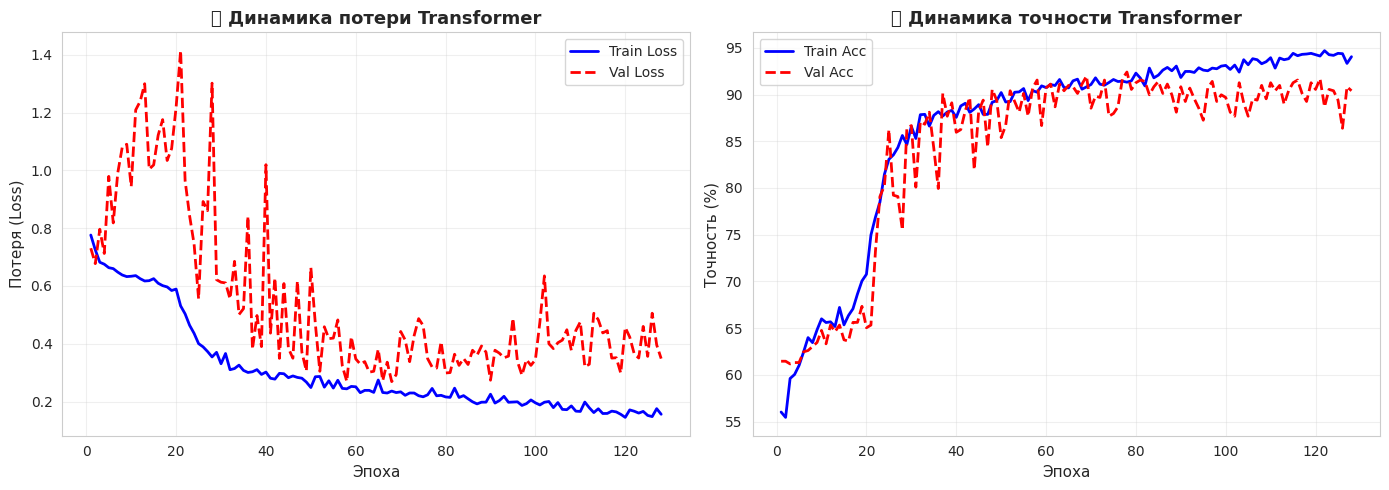

💾 График сохранён: results/Transformer_250epochs_32batch_0.0025lr_20260427_193237/Transformer_250epochs_32batch_0.0025lr_20260427_193237_training_plot.png

=== ФИНАЛЬНАЯ ОЦЕНКА ===
Финальная точность на валидации: 92.41%
ROC-AUC: 0.9658

Матрица ошибок:
[[403  24]
 [ 29 242]]

Classification Report:
              precision    recall  f1-score   support

        Good       0.93      0.94      0.94       427
         Bad       0.91      0.89      0.90       271

    accuracy                           0.92       698
   macro avg       0.92      0.92      0.92       698
weighted avg       0.92      0.92      0.92       698



/tmp/ipykernel_1696/1553965453.py:65: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1696/1553965453.py:68: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig(cm_save_path, dpi=300, bbox_inches='tight')
/home/strel/miniconda3/envs/torch-clean/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


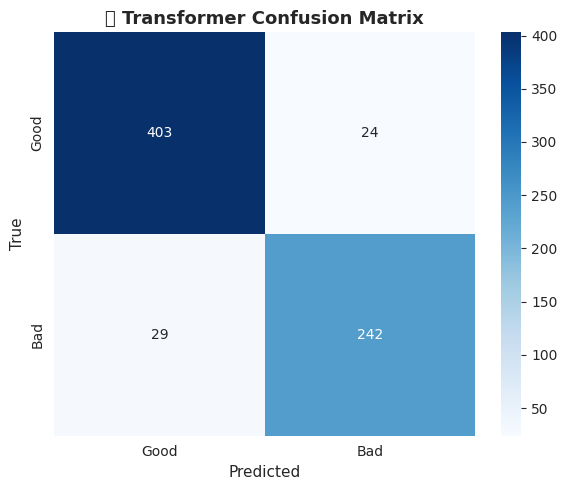

💾 Матрица ошибок сохранена: results/Transformer_250epochs_32batch_0.0025lr_20260427_193237/Transformer_250epochs_32batch_0.0025lr_20260427_193237_confusion_matrix.png
💾 Текстовый отчёт сохранён: results/Transformer_250epochs_32batch_0.0025lr_20260427_193237/Transformer_250epochs_32batch_0.0025lr_20260427_193237_classification_report.txt
💾 Веса Transformer сохранены: results/Transformer_250epochs_32batch_0.0025lr_20260427_193237/Transformer_250epochs_32batch_0.0025lr_20260427_193237_transformer_weights.pth
💾 Конфигурация сохранена: results/Transformer_250epochs_32batch_0.0025lr_20260427_193237/Transformer_250epochs_32batch_0.0025lr_20260427_193237_config.json

📁 ВСЕ ФАЙЛЫ СОХРАНЕНЫ В ПАПКУ:
   /mnt/d/Универ/ВКР/Код/ПарсингДаных/DataTransform/scientificProject/results/Transformer_250epochs_32batch_0.0025lr_20260427_193237

📄 Список сохранённых файлов:
   1. Transformer_250epochs_32batch_0.0025lr_20260427_193237_transformer_weights.pth (веса модели)
   2. Transformer_250epochs_32batch_0.0

In [23]:

# ============================================
# === СОХРАНЕНИЕ РЕЗУЛЬТАТОВ ===
# ============================================

# 📈 Построение и сохранение графика обучения
plot_training_history(history, results_dir, folder_prefix)

# 🎯 Финальная оценка на валидации
print('\n=== ФИНАЛЬНАЯ ОЦЕНКА ===')
final_loss, final_acc, y_pred, y_true = evaluate(model, val_loader, criterion, DEVICE)
print(f'Финальная точность на валидации: {final_acc:.2f}%')

# Получаем вероятности для ROC-AUC
model.eval()
y_proba_list = []
with torch.no_grad():
    for data, labels, lengths, mask in val_loader:
        data = data.to(DEVICE)
        mask = mask.to(DEVICE)
        padding_mask = (mask == 0) 
        outputs = model(data, src_key_padding_mask=mask)
        #outputs = model(data, src_key_padding_mask=padding_mask)
        proba = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        y_proba_list.extend(proba)

y_proba = np.array(y_proba_list)
y_true = np.array(y_true) # Убедитесь, что y_true тоже массив

# 🔧 ИСПРАВЛЕНИЕ: Обработка NaN значений
if np.isnan(y_proba).any():
    nan_count = np.isnan(y_proba).sum()
    print(f"⚠️ ВНИМАНИЕ: Обнаружено {nan_count} NaN значений в предсказаниях! Заменяем на 0.5 (случайное угадывание).")
    print("💡 Совет: Попробуйте уменьшить learning rate или отключить mixed precision, если NaN повторяются.")
    y_proba = np.nan_to_num(y_proba, nan=0.5)

# Теперь расчет метрики безопасен
try:
    roc_auc = roc_auc_score(y_true, y_proba)
    print(f'ROC-AUC: {roc_auc:.4f}')
except Exception as e:
    print(f"❌ Ошибка при расчете ROC-AUC: {e}")
    roc_auc = 0.0

# 📊 Матрица ошибок
cm = confusion_matrix(y_true, y_pred)
print('\nМатрица ошибок:')
print(cm)

# 📋 Classification report
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=['Good', 'Bad']))

# ============================================
# 💾 СОХРАНЕНИЕ ВСЕХ РЕЗУЛЬТАТОВ
# ============================================

# 📈 Сохраняем график матрицы ошибок
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Good', 'Bad'],
            yticklabels=['Good', 'Bad'])
plt.xlabel('Predicted', fontsize=11)
plt.ylabel('True', fontsize=11)
plt.title('🎯 Transformer Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()

cm_save_path = results_dir / f"{folder_prefix}_confusion_matrix.png"
plt.savefig(cm_save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"💾 Матрица ошибок сохранена: {cm_save_path}")

# 📄 Сохраняем текстовый отчёт
report_path = results_dir / f"{folder_prefix}_classification_report.txt"
with open(report_path, 'w', encoding='utf-8') as f:
    f.write("="*60 + "\n")
    f.write(f"PipeTransformer Classification Report\n")
    f.write(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("="*60 + "\n\n")
    f.write(f"Model Parameters:\n")
    f.write(f"  - Epochs: {EPOCHS}\n")
    f.write(f"  - Batch Size: {BATCH_SIZE}\n")
    f.write(f"  - Learning Rate: {LEARNING_RATE}\n")
    f.write(f"  - d_model: model.d_model\n")
    f.write(f"  - nhead: model.nhead\n")
    f.write(f"  - num_layers: model.num_layers\n")
    f.write(f"  - dim_feedforward: model.dim_feedforward\n")
    f.write(f"  - dropout: model.dropout\n")
    f.write(f"  - Best Val Acc: {best_val_acc:.2f}%\n\n")
    
    f.write("Classification Report:\n")
    f.write(classification_report(y_true, y_pred, target_names=['Good', 'Bad']))
    f.write("\nConfusion Matrix:\n")
    f.write(str(cm))
    f.write(f"\n\nROC-AUC: {roc_auc:.4f}\n")

print(f"💾 Текстовый отчёт сохранён: {report_path}")

# 💾 Сохраняем веса модели
model_path = results_dir / f"{folder_prefix}_transformer_weights.pth"
torch.save(model.state_dict(), model_path)
print(f"💾 Веса Transformer сохранены: {model_path}")

# 📄 Сохраняем конфигурацию эксперимента

config = {
    'model_type': 'PipeTransformer',
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'd_model': model.d_model,
    'nhead': model.nhead,
    'num_layers': model.num_layers,
    'dim_feedforward': model.dim_feedforward,
    'dropout': model.dropout,
    'best_val_acc': best_val_acc,
    'final_val_acc': final_acc,
    'roc_auc': roc_auc,
    'train_samples': len(X_train),
    'val_samples': len(X_val),
    'num_parameters': sum(p.numel() for p in model.parameters()),
    'timestamp': datetime.now().isoformat(),
    'device': str(DEVICE)
}

config_path = results_dir / f"{folder_prefix}_config.json"
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print(f"💾 Конфигурация сохранена: {config_path}")

# ============================================
# 📋 ИТОГОВАЯ ИНФОРМАЦИЯ
# ============================================

print("\n" + "="*60)
print("📁 ВСЕ ФАЙЛЫ СОХРАНЕНЫ В ПАПКУ:")
print(f"   {results_dir.absolute()}")
print("\n📄 Список сохранённых файлов:")
print(f"   1. {folder_prefix}_transformer_weights.pth (веса модели)")
print(f"   2. {folder_prefix}_training_plot.png (графики обучения)")
print(f"   3. {folder_prefix}_confusion_matrix.png (матрица ошибок)")
print(f"   4. {folder_prefix}_classification_report.txt (отчёт)")
print(f"   5. {folder_prefix}_config.json (параметры эксперимента)")
print("="*60)
